# 01.1 — Python: from values to your first image

**CPU · No downloads · Independent fresh-kernel lesson**

Read one explanation, predict one result and then run its cell. An image is a good reason to learn Python: you can see the effect of the program.

## Learning Objectives

Use variables, lists, dictionaries, conditions, loops and functions to describe a tiny image. Explain a pixel value and draw a result using Matplotlib. Compare the same data with OpenCV's color convention.

## Prerequisites

Arithmetic and the repository environment. If a cell fails to import a package, use `docs/setup.md` before continuing. No model or camera is needed.

## 1. Introduction

A variable is a name for a value. `width` can name an integer, while `label` names a string. The image we create has rows, columns and three color values per location. First calculate how many locations we need.

In [1]:
width = 3
height = 2
label = "My first image"
is_color = True
pixel_count = width * height
print(label)
print("Pixels:", pixel_count)
if is_color:
    print("Channel values:", pixel_count * 3)
assert pixel_count == 6

My first image
Pixels: 6
Channel values: 18


A **list** keeps values in order. A **dictionary** gives values names. A **tuple** is a fixed collection often used for dimensions or coordinates. Here a row is a list of pixels, and a pixel is a list of red, green and blue values. The nested structure reads row → column → channel.

In [2]:
red = [255, 0, 0]
green = [0, 255, 0]
blue = [0, 0, 255]
black = [0, 0, 0]
mid_gray = [127, 127, 127]
white = [255, 255, 255]
rows = [[red, green, blue], [black, mid_gray, white]]
settings = {"title": label, "color_order": "RGB", "brightness": 20}
position = (2, 0)  # (x, y)
print("Setting:", settings["color_order"])
print("Pixel at x=2, y=0:", rows[position[1]][position[0]])
for row_number, row in enumerate(rows):
    print("Row", row_number, "contains", len(row), "pixels")

Setting: RGB
Pixel at x=2, y=0: [0, 0, 255]
Row 0 contains 3 pixels
Row 1 contains 3 pixels


## 2. Intuition

Imagine a spreadsheet with a red layer, a green layer and a blue layer. At one location we look at all three layers together. `(255, 0, 0)` means maximum red and no green or blue. A picture is a convenient display of those numbers, not a different kind of data.

We will deliberately work with six pixels so every number can be checked by hand. Real photographs use the same storage idea at a much larger size.

## 3. Mathematical Foundation

For height $H$, width $W$ and channel count $C$, the number of stored values is $N=HWC$. Here $H=2$, $W=3$, $C=3$, so $N=18$. There are six pixel locations, each storing three values.

An 8-bit unsigned channel has $2^8=256$ possible values: 0 through 255. A full red pixel is therefore `(255, 0, 0)`. For a 10×20 RGB image, what value would $N$ have? Calculate before running a modified version of the earlier cell.

## 4. Visual Explanation

Convert the nested lists to a NumPy array. A NumPy array gives the grid a consistent numerical type. `uint8` is our chosen 0–255 storage type. Matplotlib displays RGB arrays; OpenCV is introduced separately below.

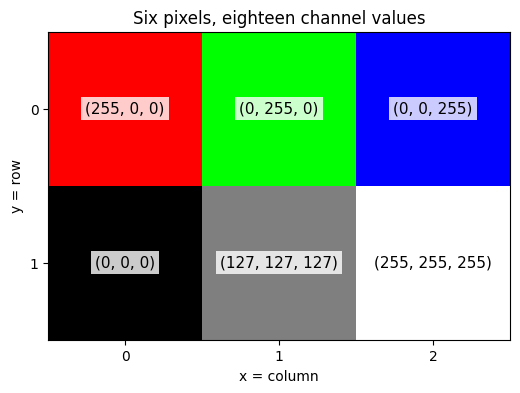

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image = np.array(rows, dtype=np.uint8)
fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(image, interpolation="nearest")
for y in range(height):
    for x in range(width):
        ax.text(
            x,
            y,
            str(tuple(int(v) for v in image[y, x])),
            ha="center",
            va="center",
            color="black",
            bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none", "pad": 3},
            fontsize=11,
        )
ax.set(
    xticks=range(width),
    yticks=range(height),
    xlabel="x = column",
    ylabel="y = row",
    title="Six pixels, eighteen channel values",
)
plt.show()

## 5. Basic Implementation

A **function** is a named recipe. Its inputs are parameters, and `return` gives a computed result back to the caller. We will first operate on one channel value. Clipping stops a value at the representable boundary. It is not the same as wrapping around.

In [4]:
def clip_channel(value):
    """Round and keep a value inside the 8-bit interval."""
    return round(min(255, max(0, value)))


def brighten_pixel(pixel, delta):
    """Create a new list; do not alter the original pixel."""
    return [clip_channel(value + delta) for value in pixel]


print("Original:", [250, 10, 0])
print("Edited:", brighten_pixel([250, 10, 0], 20))
assert brighten_pixel([250, 10, 0], 20) == [255, 30, 20]

Original: [250, 10, 0]
Edited: [255, 30, 20]


The expression inside brackets is a **list comprehension**: make one result for each original value. It is a compact loop. `print()` displays a value; it does not replace `return`. Try explaining why a function that only prints produces `None` when assigned to a variable.

## 6. OpenCV Implementation

OpenCV often represents decoded color images in **BGR** order. Our arrays are RGB. `cvtColor` uses a named conversion rule; here it swaps the first and third channels. We can check exactly what it did before trusting a picture.

Red pixel as RGB: [255, 0, 0]
Same pixel as BGR: [0, 0, 255]


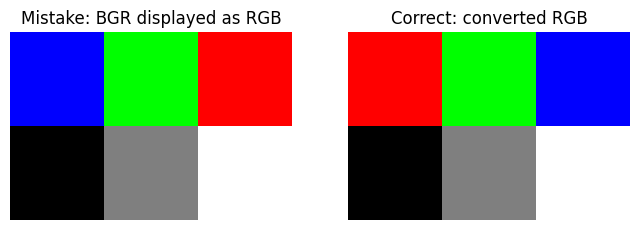

In [5]:
bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
restored_rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
print("Red pixel as RGB:", image[0, 0].tolist())
print("Same pixel as BGR:", bgr[0, 0].tolist())
np.testing.assert_array_equal(restored_rgb, image)
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(bgr, interpolation="nearest")
axes[0].set_title("Mistake: BGR displayed as RGB")
axes[1].imshow(restored_rgb, interpolation="nearest")
axes[1].set_title("Correct: converted RGB")
for ax in axes:
    ax.set_axis_off()
plt.show()

## 7. From-Scratch Implementation

Apply the single-pixel recipe to every row and column using ordinary Python lists. Empty lists collect newly created pixels and rows. There is no library brightness call hidden here: follow the three levels of the data structure.

In [6]:
def brighten_list_image(list_image, delta):
    """An explicit row/pixel/channel traversal using Python lists."""
    output = []
    for row in list_image:
        output_row = []
        for pixel in row:
            output_row.append(brighten_pixel(pixel, delta))
        output.append(output_row)
    return output


edited_lists = brighten_list_image(rows, settings["brightness"])
edited = np.array(edited_lists, dtype=np.uint8)
assert rows[0][0] == [255, 0, 0]  # input has not been changed
print("Edited first row:", edited_lists[0])

Edited first row: [[255, 20, 20], [20, 255, 20], [20, 20, 255]]


## 8. Experiment

Change `delta` to -30, 0 and 30. Predict which channels clip to 0 or 255 before running. For white, adding a positive offset cannot create a brighter stored value. For black, subtracting cannot create a negative unsigned intensity.

In [7]:
deltas = [-30, 0, 30]
experiments = {
    delta: np.array(brighten_list_image(rows, delta), dtype=np.uint8) for delta in deltas
}
for delta, output in experiments.items():
    print("Offset", delta, "black pixel becomes", output[1, 0].tolist())

Offset -30 black pixel becomes [0, 0, 0]
Offset 0 black pixel becomes [0, 0, 0]
Offset 30 black pixel becomes [30, 30, 30]


## 9. Visualization

Compare the three outputs using the same original image. RGB arrays already use the same 0–255 representation. Labeling the parameter keeps the plot connected to the code.

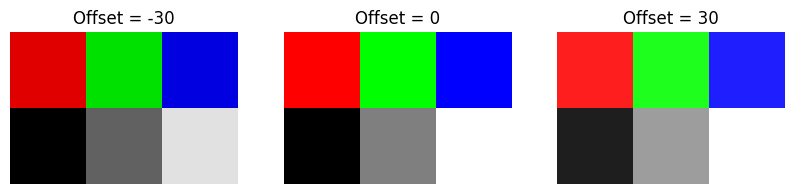

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, delta in zip(axes, deltas, strict=True):
    ax.imshow(experiments[delta], interpolation="nearest")
    ax.set_title(f"Offset = {delta}")
    ax.set_axis_off()
plt.show()

## 10. Real-World Application

This small recipe is the beginning of an image editor or preprocessing tool. A list/dictionary configuration can record the change so someone else can reproduce it. The same channel bookkeeping is necessary before classification and detection, but no model is needed to learn it.

## 11. Common Mistakes

- Treating a list of rows as a flat list of pixels.
- Swapping `(x,y)` coordinates with `[row,column]` indexing.
- Expecting `print` to return the computed array.
- Modifying the original pixel while building an output.
- Passing BGR to an RGB plotting function.

## 12. Exercises

**Easy:** replace the middle gray pixel with yellow and print its values.

**Medium:** rewrite `brighten_pixel` with an explicit loop instead of a comprehension.

**Hard:** write a function that counts how many channel values clip at the upper boundary for a chosen offset. Explain whether you count values equal to 255 before or after adding.

## 13. Challenge

Design a 5×5 pixel icon using only lists, loops and a color dictionary. Make its size configurable. Save your design choices in a dictionary, and explain how you would keep two independent versions without changing the original. No solution is included.

## 14. Summary

An image can be described using ordinary Python structures. Functions reuse a clear operation, loops apply it to the grid, and a plot makes the result visible. RGB/BGR is a data convention that must be made explicit.

## 15. Next Step

Open [02 — NumPy and pixels](02_numpy_pixels.ipynb). We will replace nested-list bookkeeping with array indexing, explain dtype overflow and use broadcasting. References: [Python tutorial](https://docs.python.org/3/tutorial/) and [OpenCV basic operations](https://docs.opencv.org/4.x/d3/df2/tutorial_py_basic_ops.html).